In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def load_experiment_data(base_dir, experiment_mapping):
    """
    複数実験の推論結果，特徴量ごとの評価指標，および被験者ごとの評価指標を
    dict構造に一括で読み込む．
    各foldのNumpy配列は (N, T, F) に自動で結合される．
    """
    data_dict = {}

    # 100倍して％表記にする対象の指標リスト
    scale_metrics = ['rmse', 'nrmse', 'mae']

    for exp_display_name , exp_name in experiment_mapping.items():
        exp_dir = os.path.join(base_dir, exp_name)
        summary_path = os.path.join(exp_dir, 'feature_summary.csv')
        
        if not os.path.exists(summary_path):
            print(f"Warning: {summary_path} が見つかりません．スキップします．")
            continue
            
        # 1. 特徴量ごとの評価指標の読み込み
        df_summary = pd.read_csv(summary_path)

        # --- 指標のスケール変換（100倍） ---
        for metric in scale_metrics:
            mean_col = f"{metric}_mean"
            std_col = f"{metric}_std"
            if mean_col in df_summary.columns:
                df_summary[mean_col] = df_summary[mean_col] * 100
            if std_col in df_summary.columns:
                df_summary[std_col] = df_summary[std_col] * 100
        
        # 2. 推論配列と実測値配列の集約
        preds_list, targets_list = [], []
        for fold in range(1, 7):  # Fold 1~6 を前提
            pred_path = os.path.join(exp_dir, f'preds_fold{fold}.npy')
            targ_path = os.path.join(exp_dir, f'targets_fold{fold}.npy')
            
            if os.path.exists(pred_path) and os.path.exists(targ_path):
                preds_list.append(np.load(pred_path))
                targets_list.append(np.load(targ_path))
                
        if not preds_list:
            print(f"Warning: {exp_name} にNumpy配列が保存されていません．")
            continue
            
        preds = np.concatenate(preds_list, axis=0)
        targets = np.concatenate(targets_list, axis=0)
        
        # 3. 被験者ごとの評価指標 (subject_summary.csv) の読み込み
        subject_path = os.path.join(exp_dir, 'subject_summary.csv')
        df_subject = None
        if os.path.exists(subject_path):
            df_subject = pd.read_csv(subject_path)
            # scale_metricsに含まれる文字列(nrmse等)が列名にあれば100倍する
            for col in df_subject.columns:
                if any(m in col for m in scale_metrics):
                    df_subject[col] = df_subject[col] * 100
        else:
            print(f"Warning: {subject_path} が見つかりません．")

        # 辞書への格納
        data_dict[exp_display_name] = {
            'summary': df_summary,
            'preds': preds,
            'targets': targets,
            'features': df_summary['feature'].tolist(),
            'subject_summary': df_subject  # 新たに追加
        }
    return data_dict

In [2]:
def create_comparison_tables(data_dict, metrics=['nrmse', 'r2']):
    """
    各指標ごとに mean±std 形式の比較表を作成して表示する．
    
    Parameters
    ----------
    data_dict : dict
        load_experiment_data() の戻り値
    metrics : list[str] or None
        表示したい指標名のリスト（例: ['rmse', 'nrmse', 'mae', 'r2']）
        None の場合は feature_summary.csv の列から自動検出
    """
    exp_names = list(data_dict.keys())
    if not exp_names:
        return

    # --- 指標名の自動検出 ---
    if metrics is None:
        cols = data_dict[exp_names[0]]['summary'].columns.tolist()
        # "_mean" で終わる列から指標名を抽出
        metrics = [c.replace('_mean', '') for c in cols if c.endswith('_mean')]

    for metric in metrics:
        mean_col = f"{metric}_mean"
        std_col  = f"{metric}_std"

        records = {}
        for exp_name in exp_names:
            df = data_dict[exp_name]['summary']

            if mean_col not in df.columns:
                continue

            row_dict = {}
            for _, row in df.iterrows():
                feature = row['feature']
                mean_val = row[mean_col]
                std_val  = row[std_col] if std_col in df.columns else float('nan')
                # "0.0215±0.0026" 形式の文字列
                row_dict[feature] = f"{mean_val:.2f}±{std_val:.2f}"

            # 全体平均（数値のみ）を最後列に追加
            row_dict['Overall_Mean'] = df[mean_col].mean()
            records[exp_name] = row_dict

        if not records:
            print(f"[{metric}] データが見つかりませんでした．スキップします．")
            continue

        df_table = pd.DataFrame.from_dict(records, orient='index')

        # Overall_Mean（数値）でソートしてから列を削除
        sort_ascending = metric != 'r2'  # r2 は高い順，誤差系は低い順
        df_table = df_table.sort_values('Overall_Mean', ascending=sort_ascending)
        df_table = df_table.drop(columns=['Overall_Mean'])

        print(f"\n{'='*60}")
        print(f"  {mean_col}  ±  {std_col}")
        print(f"{'='*60}")
        display(df_table) 


def plot_metrics_bar(data_dict, metrics=['nrmse', 'r2']):
    """
    全指標を自動検出し，指標ごとに1つの figure を作成．
    各 figure には，特徴量（Fx, Fy, Fzなど）をX軸のグループとし，
    その中に各モデル（実験）の Bar plot (+エラーバー) を並べて表示．

    Parameters
    ----------
    data_dict : dict
        load_experiment_data() の戻り値
    metrics : list[str] or None
        表示したい指標名のリスト（例: ['rmse', 'nrmse', 'mae', 'r2']）
        None の場合は feature_summary.csv の列から自動検出
    """
    exp_names = list(data_dict.keys())
    if not exp_names:
        return

    features = data_dict[exp_names[0]]['features']
    n_features = len(features)
    n_exps = len(exp_names)

    # --- 指標名の自動検出 ---
    if metrics is None:
        cols = data_dict[exp_names[0]]['summary'].columns.tolist()
        metrics = [c.replace('_mean', '') for c in cols if c.endswith('_mean')]

    # X軸の基本位置（特徴量の数分）
    x = np.arange(n_features)
    
    # 1つのグループ（特徴量）の中で各実験のバーが占める全体の幅
    total_width = 0.8
    bar_width = total_width / n_exps

    for metric in metrics:
        mean_col = f"{metric}_mean"
        std_col  = f"{metric}_std"

        # 指標が存在しない場合はスキップ
        if mean_col not in data_dict[exp_names[0]]['summary'].columns:
            print(f"[{mean_col}] が見つかりません．スキップします．")
            continue

        # 指標ごとに1つの図を作成（凡例が外に出る分，少し横幅に余裕を持たせる）
        fig, ax = plt.subplots(figsize=(8 + n_features * 0.5, 5))
        fig.suptitle(f'Metric: {metric.upper()}', fontsize=14, y=1.02)

        # 実験モデルごとにループを回し，バーを描画する
        for i, exp in enumerate(exp_names):
            means = []
            stds = []
            df = data_dict[exp]['summary']

            for feature in features:
                row = df[df['feature'] == feature]
                if not row.empty:
                    means.append(row[mean_col].values[0])
                    stds.append(row[std_col].values[0] if std_col in df.columns else 0)
                else:
                    means.append(0)
                    stds.append(0)

            # バーのX座標をずらす計算（中心を基準に等間隔で配置）
            offset = (i - n_exps / 2 + 0.5) * bar_width

            ax.bar(
                x + offset, means,
                width=bar_width, yerr=stds, capsize=5,
                label=exp, edgecolor='k', alpha=0.8
            )

        # 軸の設定
        ax.set_xticks(x)
        ax.set_xticklabels(features, fontsize=12)
        ax.set_ylabel(metric.upper(), fontsize=12)
        ax.set_title('Comparison across Features and Models')
        ax.grid(axis='y', linestyle='--', alpha=0.7)

        if metric.lower() == "r2":
            ax.set_ylim(0.60, 1.0)
        
        # 凡例の設定（図の右側に配置）
        ax.legend(title='Experiments', bbox_to_anchor=(1.02, 1), loc='upper left')

        plt.tight_layout()
        plt.show()

def plot_subject_boxplots(data_dict, metrics=['nrmse', 'r2']):
    """
    各モデルの subject_summary.csv を用いて、被験者間ばらつきの箱ひげ図を比較プロットする．
    
    Parameters
    ----------
    data_dict : dict
        load_experiment_data() の戻り値
    metrics : list[str]
        表示したい指標名のリスト（デフォルトは ['nrmse', 'r2']）
    """
    exp_names = list(data_dict.keys())
    if not exp_names:
        return

    # データに存在する特徴量のリストを取得
    features = data_dict[exp_names[0]]['features']

    for metric in metrics:
        # ----------------------------------------------------
        # 1. 全体指標 (例: nrmse, r2) の比較プロット
        # ----------------------------------------------------
        overall_data = []
        valid_exp_names = []
        
        for exp in exp_names:
            df_sub = data_dict[exp].get('subject_summary')
            if df_sub is not None and metric in df_sub.columns:
                overall_data.append(df_sub[metric].dropna().values)
                valid_exp_names.append(exp)
        
        if overall_data:
            plt.figure(figsize=(max(6, len(valid_exp_names) * 1.5), 5))
            plt.boxplot(overall_data, labels=valid_exp_names, showmeans=True)
            plt.title(f'Subject-wise Overall {metric.upper()} Comparison')
            plt.ylabel(metric.upper())
            plt.grid(True, linestyle=':', alpha=0.6)
            plt.tight_layout()
            plt.show()

        # ----------------------------------------------------
        # 2. 特徴量ごと (Fx, Fy, Fz等) の比較プロット
        # ----------------------------------------------------
        # 特徴量の数だけサブプロットを作成
        fig, axes = plt.subplots(1, len(features), figsize=(4 * len(features), 5))
        if len(features) == 1:
            axes = [axes]
            
        has_feature_data = False
        
        for i, feature in enumerate(features):
            feat_metric = f"{feature}_{metric}"
            feat_data = []
            feat_exp_names = []
            
            for exp in exp_names:
                df_sub = data_dict[exp].get('subject_summary')
                if df_sub is not None and feat_metric in df_sub.columns:
                    feat_data.append(df_sub[feat_metric].dropna().values)
                    feat_exp_names.append(exp)
            
            if feat_data:
                has_feature_data = True
                axes[i].boxplot(feat_data, labels=feat_exp_names, showmeans=True)
                axes[i].set_title(f'{feat_metric.upper()}')
                axes[i].set_ylabel(metric.upper())
                axes[i].grid(True, linestyle=':', alpha=0.6)
                
        if has_feature_data:
            plt.tight_layout()
            plt.suptitle(f'Feature-specific {metric.upper()} Comparison', y=1.05, fontsize=14)
            plt.show()
        else:
            plt.close(fig) 

In [3]:
def plot_waveform_comparison(data_dict):
    """全モデルの平均予測波形と、真値の(平均±1SD帯)を重ねて可視化"""
    exp_names = list(data_dict.keys())
    if not exp_names: return
    features = data_dict[exp_names[0]]['features']
    
    n_features = len(features)
    n_cols = min(3, n_features)
    n_rows = int(np.ceil(n_features / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    if n_features == 1: axes = np.array([axes])
    axes = axes.flatten()
    
    # ターゲット波形テンソルを基準に時間軸(%)を定義
    base_targets = data_dict[exp_names[0]]['targets']
    time_pts = np.linspace(0, 100, base_targets.shape[1])
    
    for i, feature in enumerate(features):
        ax = axes[i]
        
        # 真値の計算（Nサンプル方向への平均）
        true_mean = np.mean(base_targets[:, :, i], axis=0)
        true_std = np.std(base_targets[:, :, i], axis=0)
        
        # 真値をプロットとグレー帯域塗布
        ax.plot(time_pts, true_mean, label='True Mean', color='black', lw=2)
        ax.fill_between(time_pts, true_mean - true_std, true_mean + true_std, color='gray', alpha=0.2, label='True ±1SD')
        
        # モデルごとの予測推移を実線で重畳
        for exp in exp_names:
            preds = data_dict[exp]['preds']
            pred_mean = np.mean(preds[:, :, i], axis=0)
            ax.plot(time_pts, pred_mean, label=f'{exp}', linestyle='--')
            
        ax.set_title(f'Waveforms: {feature}')
        ax.set_xlabel('Gait Cycle (%)')
        ax.set_ylabel('Amplitude')
        ax.legend(fontsize='small', loc='upper right')
        ax.grid(True, linestyle=':', alpha=0.6)
        
    for j in range(i + 1, len(axes)): fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()

def plot_error_time_series(data_dict):
    """Error = Pred - Trueの平均・標準偏差帯を時間方向でプロット"""
    exp_names = list(data_dict.keys())
    if not exp_names: return
    features = data_dict[exp_names[0]]['features']
    
    n_features = len(features)
    n_cols = min(3, n_features)
    n_rows = int(np.ceil(n_features / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    if n_features == 1: axes = np.array([axes])
    axes = axes.flatten()
    
    time_pts = np.linspace(0, 100, data_dict[exp_names[0]]['targets'].shape[1])
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    
    for i, feature in enumerate(features):
        ax = axes[i]
        
        for idx, exp in enumerate(exp_names):
            error = data_dict[exp]['preds'][:, :, i] - data_dict[exp]['targets'][:, :, i]
            mean_error = np.mean(error, axis=0)
            std_error = np.std(error, axis=0)
            
            c = colors[idx % len(colors)]
            ax.plot(time_pts, mean_error, label=exp, color=c)
            # エラー誤差幅の帯
            ax.fill_between(time_pts, mean_error - std_error, mean_error + std_error, color=c, alpha=0.1)
            
        ax.axhline(0, color='black', lw=1.5)  # 誤差0のベースライン
        ax.set_title(f'Error Evolution: {feature}')
        ax.set_xlabel('Gait Cycle (%)')
        ax.set_ylabel('Error (Pred - True)')
        ax.legend(fontsize='x-small', loc='best')
        ax.grid(True, linestyle=':', alpha=0.6)
        
    for j in range(i + 1, len(axes)): fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()



  nrmse_mean  ±  nrmse_std


,Fx,Fy,Fz
edge 0.5 to 0.5,7.96±1.05,4.96±0.93,5.35±0.95
HS-TO,8.45±1.44,4.98±0.80,5.24±0.23



  r2_mean  ±  r2_std


,Fx,Fy,Fz
edge 0.5 to 0.5,0.77±0.05,0.92±0.04,0.94±0.02
HS-TO,0.74±0.07,0.92±0.03,0.94±0.01


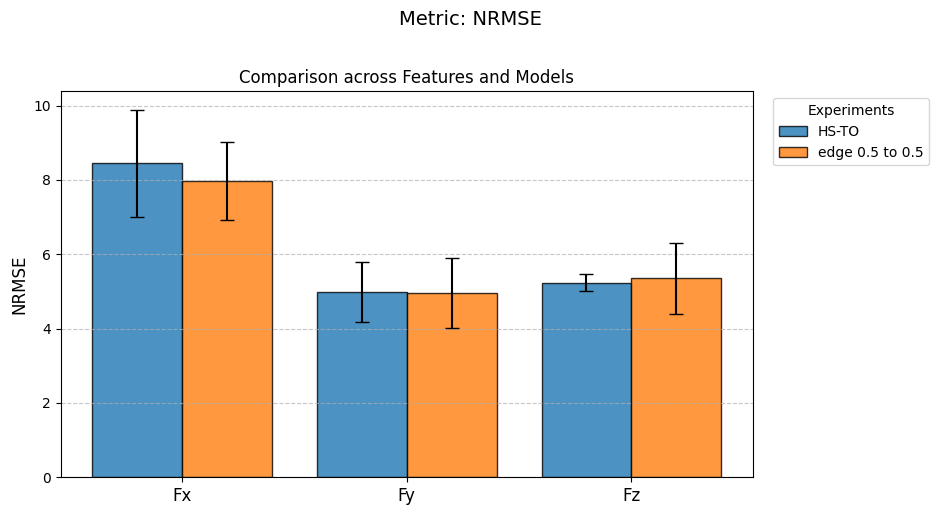

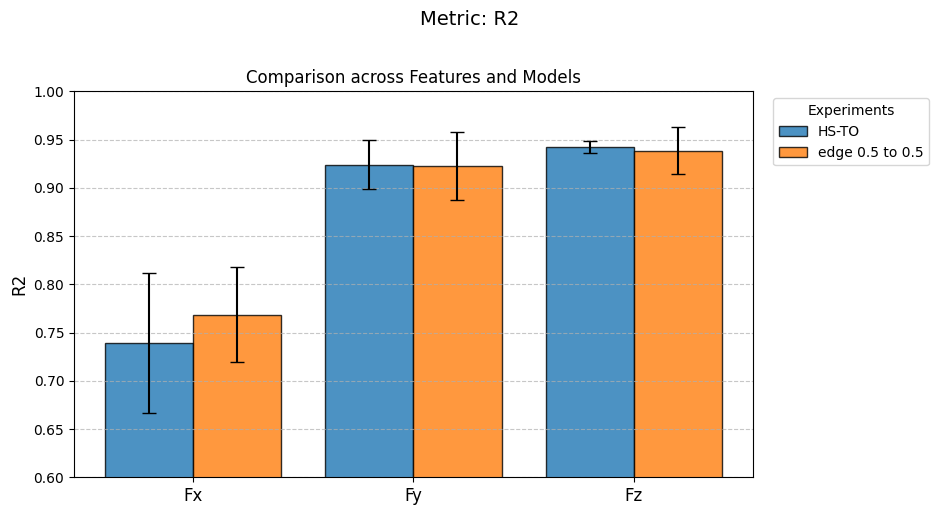

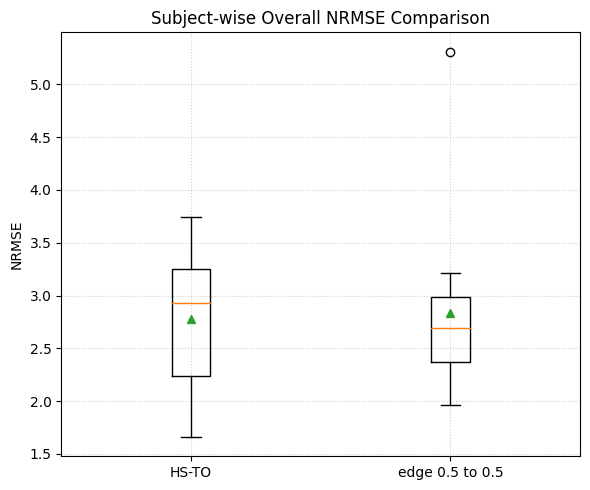

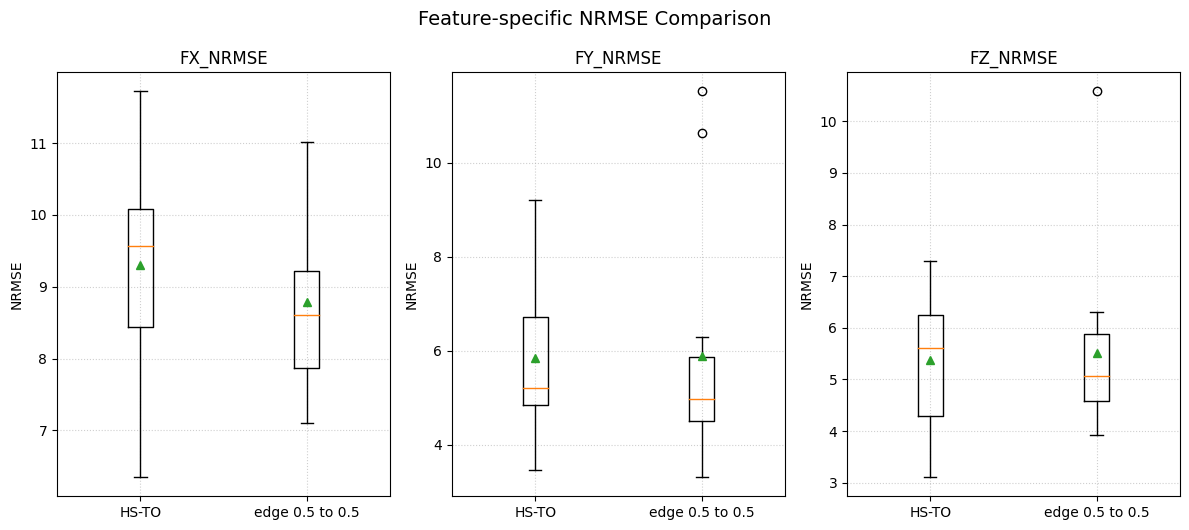

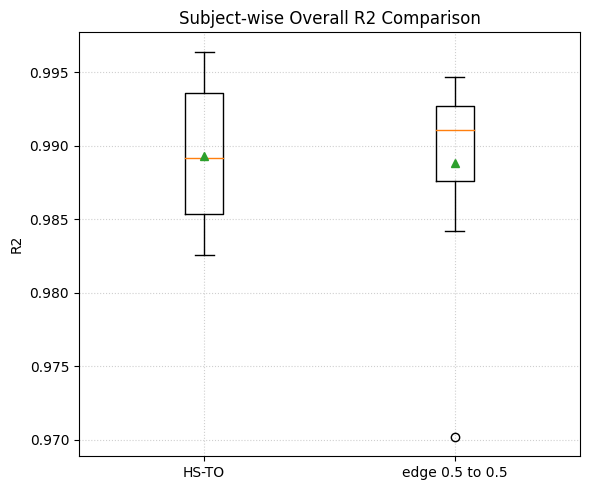

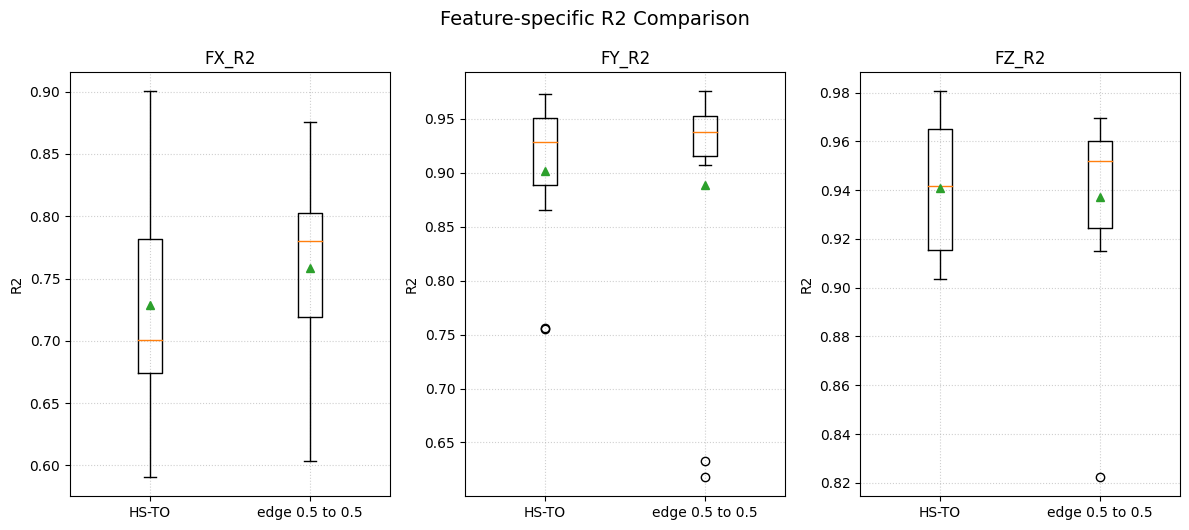

In [4]:
# 対象の実験ディレクトリが格納されている親パス
BASE_DIR = "../outputs/experiments"

# 比較したい実験リストを直接書くか、glob等で取得します
experiments = {
    # "CNN": "cnn_grf_single_cnn_20260421_040528",
    # "CNN-Light": "cnn_grf_single_light_cnn_20260610_042904",
    # "BiLSTM": "bilstm_grf_single_bilstm_20260421_040951",
    # "BiLSTM-Light": "bilstm_grf_single_light_bilstm_20260610_043359",
    # "TO-TO": "transformer_X_1.0_pre_swing_Y_0.5_transformer_20260707_053726",
    # "Transformer-fixed": "transformer_grf_single_weighted_transformer_20260421_055208",
    # "Transformer-Pressure": "transformer_grf_pressure_single_weighted_transformer_20260421_074422",
    # "Transformer-std":"transformer_grf_single_weighted_std_transformer_20260611_040709",
    # "Transformer-var":"transformer_grf_single_weighted_var_transformer_20260611_042543",
    # "Transformer-standardized":"transformer_grf_single_standardized_transformer_20260611_071713",
    # "Transformer": "transformer_grf_single_transformer_20260421_053321",
    "HS-TO": "transformer_X_0.5_Y_0.5_transformer_20260707_052451",
    # "0.5 to 0.5 z": "transformer_X_0.5_Y_0.5_stdY_transformer_20260708_021511",
    # "0.5 to post": "transformer_X_0.5_Y_1.0_post_swing_transformer_20260707_064601",
    # "0.5 to post z": "transformer_X_0.5_Y_1.0_post_swing_stdY_transformer_20260708_025843",
    # "HS-HS": "transformer_X_1.0_post_swing_Y_0.5_transformer_20260707_054836",
    # "post to 0.5 z": "transformer_X_1.0_post_swing_Y_0.5_stdY_transformer_20260708_023547",
    # "post to post": "transformer_X_1.0_post_swing_Y_1.0_post_swing_transformer_20260707_071124",
    # "post to post z": "transformer_X_1.0_post_swing_Y_1.0_post_swing_stdY_transformer_20260708_032319",

    # "pre to 0.5 z": "transformer_X_1.0_pre_swing_Y_0.5_stdY_transformer_20260708_022522",
    # "pre to post": "transformer_X_1.0_pre_swing_Y_1.0_post_swing_transformer_20260707_065742",
    # "pre to post z": "transformer_X_1.0_pre_swing_Y_1.0_post_swing_stdY_transformer_20260708_031126",
    # "1.5 to 0.5": "transformer_X_1.5_Y_0.5_transformer_20260707_060238",
    # "1.5 to 0.5 z": "transformer_X_1.5_Y_0.5_stdY_transformer_20260708_024819", 
    # "1.5 to post": "transformer_X_1.5_Y_1.0_post_swing_transformer_20260707_072757",
    # "1.5 to post z": "transformer_X_1.5_Y_1.0_post_swing_stdY_transformer_20260708_033621",
    # "Bilateral": "transformer_X_0.5_Y_0.5_bi_transformer_20260709_080921",
    # "bi 0.5 to 0.5 z": "transformer_X_0.5_Y_0.5_stdY_bi_transformer_20260709_041606",
    # "bi 0.5 to post": "transformer_X_0.5_Y_1.0_post_swing_bi_transformer_20260709_091610",
    # "bi 0.5 to post z": "transformer_X_0.5_Y_1.0_post_swing_stdY_bi_transformer_20260709_050838",
    # "bi post to 0.5": "transformer_X_1.0_post_swing_Y_0.5_bi_transformer_20260709_084644",
    # "bi post to 0.5 z": "transformer_X_1.0_post_swing_Y_0.5_stdY_bi_transformer_20260709_044144",
    # "bi post to post": "transformer_X_1.0_post_swing_Y_1.0_post_swing_bi_transformer_20260709_094631",
    # "bi post to post z": "transformer_X_1.0_post_swing_Y_1.0_post_swing_stdY_bi_transformer_20260709_053737",
    # "bi pre to 0.5": "transformer_X_1.0_pre_swing_Y_0.5_bi_transformer_20260709_082904",
    # "bi pre to 0.5 z": "transformer_X_1.0_pre_swing_Y_0.5_stdY_bi_transformer_20260709_042841",
    # "bi pre to post": "transformer_X_1.0_pre_swing_Y_1.0_post_swing_bi_transformer_20260709_093121",
    # "bi pre to post z": "transformer_X_1.0_pre_swing_Y_1.0_post_swing_stdY_bi_transformer_20260709_052219",
    # "bi 1.5 to 0.5": "transformer_X_1.5_Y_0.5_bi_transformer_20260709_090323",
    # "bi 1.5 to 0.5 z": "transformer_X_1.5_Y_0.5_stdY_bi_transformer_20260709_045700", 
    # "bi 1.5 to post": "transformer_X_1.5_Y_1.0_post_swing_bi_transformer_20260709_100542",
    # "bi 1.5 to post z": "transformer_X_1.5_Y_1.0_post_swing_stdY_bi_transformer_20260709_055205"
    # "gelu 0.5 to 0.5": "gelu_X_0.5_Y_0.5_transformer_gelu_20260729_031559",
    # "gelu post to 0.5": "gelu_X_1.0_post_swing_Y_0.5_transformer_gelu_20260729_034322",
    # "gelu pre to 0.5": "gelu_X_1.0_pre_swing_Y_0.5_transformer_gelu_20260729_033015",
    # "gelu 1.5 to 0.5": "gelu_X_1.5_Y_0.5_transformer_gelu_20260729_035755",
    # "gcn 0.5 to 0.5": "hybrid_grf_single_0.5_hybrid_grf_20260730_035140",
    # "gcn post to 0.5": "hybrid_grf_single_post_swing_hybrid_grf_20260730_043130",
    # "gcn pre to 0.5": "hybrid_grf_single_pre_swing_hybrid_grf_20260730_040926",
    # "gcn 1.5 to 0.5": "hybrid_grf_single_1.5_hybrid_grf_20260730_044729",
    # "gan 0.5 to 0.5": "hybrid_gat_X_0.5_Y_0.5_hybrid_gat_20260731_082852",
    # "gan post to 0.5": "hybrid_gat_X_1.0_post_swing_Y_0.5_hybrid_gat_20260731_091320",
    # "gan pre to 0.5": "hybrid_gat_X_1.0_pre_swing_Y_0.5_hybrid_gat_20260731_085009",
    # "gan 1.5 to 0.5": "hybrid_gat_X_1.5_Y_0.5_hybrid_gat_20260731_093729",
    "edge 0.5 to 0.5": "hybrid_edge_X_0.5_Y_0.5_hybrid_edge_20260731_070706",
    # "edge post to 0.5": "hybrid_edge_X_1.0_post_swing_Y_0.5_hybrid_edge_20260731_075043",
    # "edge pre to 0.5": "hybrid_edge_X_1.0_pre_swing_Y_0.5_hybrid_edge_20260731_073118",
    # "edge 1.5 to 0.5": "hybrid_edge_X_1.5_Y_0.5_hybrid_edge_20260731_080736",
    # "residual 0.5 to 0.5": "hybrid_gcn_res_X_0.5_Y_0.5_hybrid_gcn_res_20260731_100219",
    # "residual post to 0.5": "",
    # "residual pre to 0.5": "",
    # "residual 1.5 to 0.5": "",
    # "Without IMU": "transformer_grf_pressure_single_X_0.5_Y_0.5_transformer_20260807_045753",
    # "IMU off post to 0.5": "transformer_grf_pressure_single_X_1.0_post_swing_Y_0.5_transformer_20260807_051418",
    # "IMU off pre to 0.5": "transformer_grf_pressure_single_X_1.0_pre_swing_Y_0.5_transformer_20260807_050511",
}

# 1. データのロード
data = load_experiment_data(BASE_DIR, experiments)

# 2. 定量評価の表示
df_r2 = create_comparison_tables(data)

# 3. Bar Plot の表示
plot_metrics_bar(data) 

# 4. 被験者間ばらつきの箱ひげ図の表示
plot_subject_boxplots(data, metrics=['nrmse', 'r2'])

# # 4. 波形比較の表示
# plot_waveform_comparison(data)

# # 5. 時間軸エラー分析の表示
# plot_error_time_series(data)

